functional statements, constraints, invariants, negative requirements,
edge cases, and prioritization rules.

In [ ]:
import pandas as pd
import ast
import statsmodels.api as sm
import numpy as np


# Process data

In [ ]:
def safe_literal_eval(val):
    if pd.isna(val):
        return None  # or [] if you prefer an empty list
    return ast.literal_eval(val)

def has_any_dict(row):
    if not row or row == [None]:  # handle empty or None
        return 0
    for d in row:  # row is a list of dicts
        if any(v for v in d.values() if isinstance(v, str) and v.strip()):
            return 1
    return 0

In [ ]:
path = "Datasets/RQ3.csv"
df = pd.read_csv(path)
df["before_ac"] = df["before_ac"].apply(safe_literal_eval)
df["before_frs"] = df["before_frs"].apply(safe_literal_eval)
df["before_invariants"] = df["before_invariants"].apply(safe_literal_eval)
df["before_neg_req"] = df["before_neg_req"].apply(safe_literal_eval)
df["before_constraints"] = df["before_constraints"].apply(safe_literal_eval)

df["Has_AC"] = 0; df["Has_Excp"] = 0; 
df["Has_FR"] = 0; df["Has_INV"] = 0; 
df["Has_Neg_RE"] = 0; df["Has_TB"] = 0; 
df["Has_const"] = 0

# Apply function to create a flag column
df['Has_AC'] = df['before_ac'].apply(has_any_dict)
df['Has_FR'] = df['before_frs'].apply(has_any_dict)
df['Has_INV'] = df['before_invariants'].apply(has_any_dict)
df['Has_const'] = df['before_constraints'].apply(has_any_dict)
df['Has_Neg_RE'] = df['before_neg_req'].apply(has_any_dict)

# Convert non-empty string check to 0/1
df['Has_Excp'] = df['before_exception'].apply(
    lambda x: int(isinstance(x, str) and x.strip() != '')
)

df['Has_TB'] = df['before_tie_breaking'].apply(
    lambda x: int(isinstance(x, str) and x.strip() != '')
)

cols_to_drop = ["before_ac", "before_exception", "before_frs", "before_invariants", "before_neg_req", "before_tie_breaking", "before_constraints"]
df = df.drop(columns=cols_to_drop)
df.to_csv("Datasets/RQ3.csv", index=False)

# Logistic regression with hidden test sucess as binary: Constrain does not work

In [ ]:
df = pd.read_csv("Datasets/RQ3.csv")

In [ ]:
# Select your predictors
predictors = ['Has_AC', 'Has_Excp', 'Has_FR', 'Has_INV', 'Has_Neg_RE', 'Has_TB']

X = df[predictors]
y = (df['num_hidden_test_passed_phase1'] > 0).astype(int)

# Drop columns with zero variance
X = X.loc[:, X.nunique() > 1]

# Drop perfectly correlated columns
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] == 1)]
if to_drop:
    print("Dropping perfectly correlated columns:", to_drop)
    X = X.drop(columns=to_drop)

# Add intercept
X = sm.add_constant(X)

# Fit logistic regression
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Dropping perfectly correlated columns: ['Has_Neg_RE']
         Current function value: 0.051954
         Iterations: 35
                                 Logit Regression Results                                
Dep. Variable:     num_hidden_test_passed_phase1   No. Observations:                   72
Model:                                     Logit   Df Residuals:                       66
Method:                                      MLE   Df Model:                            5
Date:                           Fri, 20 Mar 2026   Pseudo R-squ.:                  0.2902
Time:                                   19:21:17   Log-Likelihood:                -3.7407
converged:                                 False   LL-Null:                       -5.2697
Covariance Type:                       nonrobust   LLR p-value:                    0.6910
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
co

/Users/elmiraonagh/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
# Get coefficients and p-values
coef = logit_model.params
pvals = logit_model.pvalues

# Convert to odds ratios
odds_ratios = np.exp(coef)

# Create summary table
summary_table = pd.DataFrame({
    'Requirement Element': odds_ratios.index,
    'Odds Ratio': odds_ratios.values,
    'p-value': pvals.values
})

# Remove the intercept
summary_table = summary_table[summary_table['Requirement Element'] != 'const']

# Format odds ratio and p-value nicely
summary_table['Odds Ratio'] = summary_table['Odds Ratio'].map(lambda x: f"{x:.2f}×")
summary_table['p-value'] = summary_table['p-value'].map(lambda x: f"< 0.001" if x < 0.001 else f"{x:.3f}")

# Sort by odds ratio descending
summary_table = summary_table.sort_values(by='Odds Ratio', key=lambda x: x.str.replace("×","").astype(float), ascending=False)

print(summary_table)

  Requirement Element Odds Ratio p-value
1              Has_AC      4.07×   1.000
3              Has_FR      1.22×   1.000
4             Has_INV      0.89×   1.000
5              Has_TB      0.34×   1.000
2            Has_Excp      0.00×   1.000


# Binomical regression: hiddent test pass proportion

proportion of hidden tests passed, weighted by total tests.

In [ ]:
df = pd.read_csv("Datasets/RQ3.csv")

# Total hidden tests
df['hidden_total'] = df['num_hidden_test_passed_phase1'] + df['num_hidden_test_failed_phase1']

# Proportion of hidden tests passed
df['hidden_success_prop'] = df['num_hidden_test_passed_phase1'] / df['hidden_total']

# Keep only rows with at least one hidden test
df_binom = df[df['hidden_total'] > 0]

predictors = ['Has_AC', 'Has_Excp', 'Has_FR', 'Has_INV', 'Has_Neg_RE', 'Has_TB', 'Has_const']
X = df_binom[predictors]

# Drop columns with no variation
X = X.loc[:, X.nunique() > 1]

# Add intercept
X = sm.add_constant(X)

# GLM with Binomial family: y = proportion, weights = total trials
y = df_binom['hidden_success_prop']
weights = df_binom['hidden_total']

model = sm.GLM(y, X, family=sm.families.Binomial(), freq_weights=weights)
result = model.fit()

print(result.summary())

                  Generalized Linear Model Regression Results                  
Dep. Variable:     hidden_success_prop   No. Observations:                   72
Model:                             GLM   Df Residuals:                     2370
Model Family:                 Binomial   Df Model:                            5
Link Function:                   Logit   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:                -1055.7
Date:                 Fri, 20 Mar 2026   Deviance:                       234.75
Time:                         19:21:50   Pearson chi2:                     203.
No. Iterations:                     11   Pseudo R-squ. (CS):             0.9495
Covariance Type:             nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.6124      0.073     -8.39

In [7]:
odds_ratios = np.exp(result.params)
pvals = result.pvalues

summary_table = pd.DataFrame({
    'Requirement Element': odds_ratios.index,
    'Odds Ratio': odds_ratios.values,
    'p-value': pvals.values
})

# Remove intercept
summary_table = summary_table[summary_table['Requirement Element'] != 'const']

# Format nicely
summary_table['Odds Ratio'] = summary_table['Odds Ratio'].map(lambda x: f"{x:.2f}×")
summary_table['p-value'] = summary_table['p-value'].map(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

# Sort descending
summary_table = summary_table.sort_values(by='Odds Ratio', key=lambda x: x.str.replace("×","").astype(float), ascending=False)

print(summary_table)

  Requirement Element Odds Ratio  p-value
3              Has_FR      2.69×  < 0.001
4             Has_INV      2.41×    0.007
5          Has_Neg_RE      2.41×    0.007
7           Has_const      1.83×  < 0.001
1              Has_AC      0.68×    0.006
2            Has_Excp      0.57×    0.004
6              Has_TB      0.17×    0.001


# binomial regression: pass and fail counts

In [ ]:
df = pd.read_csv("Datasets/RQ3.csv")

# Number of successes and total trials
df['hidden_success_total'] = df['num_hidden_test_passed_phase1'] + df['num_hidden_test_failed_phase1']
df['hidden_success_prop'] = df['num_hidden_test_passed_phase1'] / df['hidden_success_total']

# Keep only rows with at least one hidden test
df_binom = df[df['hidden_success_total'] > 0]

predictors = ['Has_AC', 'Has_Excp', 'Has_FR', 'Has_INV', 'Has_Neg_RE', 'Has_TB', 'Has_const']
X = df_binom[predictors]

# Drop columns with zero variance
X = X.loc[:, X.nunique() > 1]

# Response: successes and failures
y = df_binom[['num_hidden_test_passed_phase1', 'num_hidden_test_failed_phase1']]

# Add intercept
X = sm.add_constant(X)

# Fit model using the binomial family
logit_model = sm.GLM(y, X, family=sm.families.Binomial()).fit()
print(logit_model.summary())

                                         Generalized Linear Model Regression Results                                          
Dep. Variable:     ['num_hidden_test_passed_phase1', 'num_hidden_test_failed_phase1']   No. Observations:                   72
Model:                                                                            GLM   Df Residuals:                       66
Model Family:                                                                Binomial   Df Model:                            5
Link Function:                                                                  Logit   Scale:                          1.0000
Method:                                                                          IRLS   Log-Likelihood:                -249.09
Date:                                                                Fri, 20 Mar 2026   Deviance:                       234.75
Time:                                                                        19:22:39   Pearson chi2:          

In [10]:
# Extract odds ratios and p-values
odds_ratios = np.exp(logit_model.params)
pvals = logit_model.pvalues

summary_table = pd.DataFrame({
    'Requirement Element': odds_ratios.index,
    'Odds Ratio': odds_ratios.values,
    'p-value': pvals.values
})

# Remove intercept
summary_table = summary_table[summary_table['Requirement Element'] != 'const']

# Format nicely
summary_table['Odds Ratio'] = summary_table['Odds Ratio'].map(lambda x: f"{x:.2f}×")
summary_table['p-value'] = summary_table['p-value'].map(lambda x: "< 0.001" if x < 0.001 else f"{x:.3f}")

# Sort by odds ratio descending
summary_table = summary_table.sort_values(by='Odds Ratio', key=lambda x: x.str.replace("×","").astype(float), ascending=False)

print(summary_table)

  Requirement Element Odds Ratio  p-value
3              Has_FR      2.69×  < 0.001
4             Has_INV      2.41×    0.007
5          Has_Neg_RE      2.41×    0.007
7           Has_const      1.83×  < 0.001
1              Has_AC      0.68×    0.006
2            Has_Excp      0.57×    0.004
6              Has_TB      0.17×    0.001


# Visualization

Shape: (72, 14)
Columns: ['specification', 'Task', 'passed_tests_phase1', 'failed_tests_phase1', 'num_hidden_test_passed_phase1', 'num_hidden_test_failed_phase1', 'Has_AC', 'Has_Excp', 'Has_FR', 'Has_INV', 'Has_Neg_RE', 'Has_TB', 'Has_const', 'anon_id']
                 Generalized Linear Model Regression Results                  
Dep. Variable:           ['y1', 'y2']   No. Observations:                   72
Model:                            GLM   Df Residuals:                       66
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -249.09
Date:                Fri, 27 Mar 2026   Deviance:                       234.75
Time:                        15:33:06   Pearson chi2:                     203.
No. Iterations:                    11   Pseudo R-squ. (CS):             0.9495
Covariance Type:            nonrobu

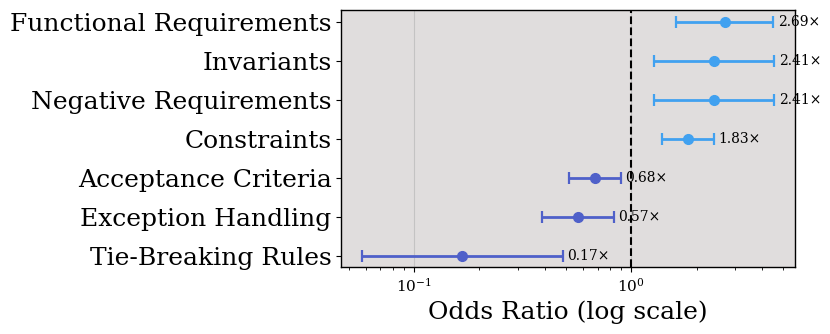


Table-ready values:
                  label  odds_ratio  ci_low  ci_high p_value
     Tie-Breaking Rules        0.17    0.06     0.49   0.001
     Exception Handling        0.57    0.39     0.83   0.004
    Acceptance Criteria        0.68    0.51     0.90   0.006
            Constraints        1.83    1.39     2.41  <0.001
  Negative Requirements        2.41    1.28     4.55   0.007
             Invariants        2.41    1.28     4.55   0.007
Functional Requirements        2.69    1.61     4.51  <0.001


In [ ]:
# ==========================================
# RQ3 Figure: Forest Plot of Requirement Effects
# Google Colab code
# Styled to align with RQ1 / RQ2 visuals
# ==========================================

# !pip -q install pandas numpy matplotlib statsmodels openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
# from google.colab import files

# -----------------------------
# Global style to match RQ1/RQ2
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "grid.color": "#bdbdbd",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.8,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

# -----------------------------
# Upload file
# -----------------------------
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]

# # Works for CSV or Excel
# if filename.lower().endswith(".csv"):
#     df = pd.read_csv("Datasets/RQ3.csv")
# elif filename.lower().endswith((".xlsx", ".xls")):
#     df = pd.read_excel(filename)
# else:
#     raise ValueError("Please upload a CSV or Excel file.")

df = pd.read_csv("Datasets/RQ3.csv")

# print("Loaded:", filename)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

# -----------------------------
# Required columns
# -----------------------------
required_cols = [
    "num_hidden_test_passed_phase1",
    "num_hidden_test_failed_phase1",
    "Has_AC",
    "Has_Excp",
    "Has_FR",
    "Has_INV",
    "Has_Neg_RE",
    "Has_TB",
    "Has_const",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# -----------------------------
# Prepare predictors
# -----------------------------
predictor_cols = ["Has_AC", "Has_Excp", "Has_FR", "Has_INV", "Has_Neg_RE", "Has_TB", "Has_const"]

# Ensure numeric 0/1
for c in predictor_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

# Binomial outcome as successes / failures
y = np.column_stack([
    df["num_hidden_test_passed_phase1"].values,
    df["num_hidden_test_failed_phase1"].values
])

X = sm.add_constant(df[predictor_cols])

# -----------------------------
# Fit weighted binomial GLM
# -----------------------------
model = sm.GLM(y, X, family=sm.families.Binomial())
result = model.fit()

print(result.summary())

# -----------------------------
# Extract odds ratios and CIs
# -----------------------------
params = result.params
conf = result.conf_int()
pvals = result.pvalues

or_vals = np.exp(params)
or_low = np.exp(conf[0])
or_high = np.exp(conf[1])

plot_df = pd.DataFrame({
    "term": params.index,
    "odds_ratio": or_vals,
    "ci_low": or_low,
    "ci_high": or_high,
    "p_value": pvals
})

plot_df = plot_df[plot_df["term"] != "const"].copy()

label_map = {
    "Has_FR": "Functional Requirements",
    "Has_INV": "Invariants",
    "Has_Neg_RE": "Negative Requirements",
    "Has_const": "Constraints",
    "Has_AC": "Acceptance Criteria",
    "Has_Excp": "Exception Handling",
    "Has_TB": "Tie-Breaking Rules",
}

plot_df["label"] = plot_df["term"].map(label_map)

# Desired display order, strongest positive to strongest negative
display_order = [
    "Functional Requirements",
    "Invariants",
    "Negative Requirements",
    "Constraints",
    "Acceptance Criteria",
    "Exception Handling",
    "Tie-Breaking Rules",
]

plot_df["label"] = pd.Categorical(plot_df["label"], categories=display_order, ordered=True)
plot_df = plot_df.sort_values("label", ascending=False).reset_index(drop=True)

# -----------------------------
# Colors aligned with your figures
# -----------------------------
pastel_blue = "#41a1f0"   # similar to RQ1 light blue
dark_blue = "#4f60c9"     # similar to RQ1/RQ2 darker blue
black = "#000000"

# positive OR > 1 gets pastel blue, negative association gets darker blue
plot_df["color"] = np.where(plot_df["odds_ratio"] >= 1.0, pastel_blue, dark_blue)

# -----------------------------
# Forest plot
# -----------------------------
fig, ax = plt.subplots(figsize=(8.4, 3.5))
ax.set_facecolor("#e0dddd")

y_pos = np.arange(len(plot_df))

for i, row in plot_df.iterrows():
    ax.errorbar(
        x=row["odds_ratio"],
        y=i,
        xerr=[[row["odds_ratio"] - row["ci_low"]], [row["ci_high"] - row["odds_ratio"]]],
        fmt='o',
        color=row["color"],
        ecolor=row["color"],
        markerfacecolor=row["color"],
        markeredgecolor=row["color"],
        markersize=7,
        elinewidth=2,
        capsize=4,
        capthick=1.6,
        zorder=3
    )

# Reference line at OR = 1
ax.axvline(1.0, color=black, linestyle='--', linewidth=1.5, zorder=2)

# Log scale is standard for OR plots
ax.set_xscale("log")

# Y labels
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["label"], fontsize=18)

# Labels and title
ax.set_xlabel("Odds Ratio (log scale)", fontsize = 18)
# ax.set_title("Requirement Elements and Hidden-Test Success")

# Grid aligned with previous figures
ax.grid(True, axis="x")
ax.grid(False, axis="y")

# Black spines
for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(1.0)

# Optional numeric annotations
for i, row in plot_df.iterrows():
    x_text = row["ci_high"] * 1.05
    ax.text(
        x_text,
        i,
        f"{row['odds_ratio']:.2f}×",
        va="center",
        ha="left",
        fontsize=10,
        color="black"
    )

plt.tight_layout()

# Save outputs


pdf_name = "RQ3_forest_plot.pdf"

plt.savefig(
    pdf_name,
    bbox_inches="tight",
    facecolor="white",     # ensures white background
    edgecolor="white"      # avoids gray borders
)

plt.show()

# files.download(pdf_name)

# -----------------------------
# Optional table output for paper
# -----------------------------
table_df = plot_df[["label", "odds_ratio", "ci_low", "ci_high", "p_value"]].copy()
table_df["odds_ratio"] = table_df["odds_ratio"].round(2)
table_df["ci_low"] = table_df["ci_low"].round(2)
table_df["ci_high"] = table_df["ci_high"].round(2)
table_df["p_value"] = table_df["p_value"].apply(lambda x: "<0.001" if x < 0.001 else f"{x:.3f}")

print("\nTable-ready values:")
print(table_df.to_string(index=False))

RQ3 columns: ['specification', 'Task', 'passed_tests_phase1', 'failed_tests_phase1', 'num_hidden_test_passed_phase1', 'num_hidden_test_failed_phase1', 'Has_AC', 'Has_Excp', 'Has_FR', 'Has_INV', 'Has_Neg_RE', 'Has_TB', 'Has_const', 'anon_id']
Failure-mode columns: ['version', 'specification', 'Task', 'failed_categories', 'passed_categories', 'anon_id']

Rows in RQ3.csv: 72
Rows in failure_modes_phase1.csv: 72
Rows after merge: 72

Reduction matrix:
                               CO        IV        TB        EC        AI
Functional Requirements  0.041667  0.333333  0.020833  0.083333  0.333333
Invariants               0.043478  0.347826  0.020408  0.086957  0.347826
Negative Requirements    0.043478  0.347826  0.020408  0.086957  0.347826
Constraints              0.021277  0.170213  0.040000  0.042553  0.170213
Acceptance Criteria     -0.020408 -0.163265  0.020408 -0.040816 -0.163265
Exception Handling      -0.017857  0.178571  0.017857 -0.035714  0.178571
Tie-Breaking Rules       0.047

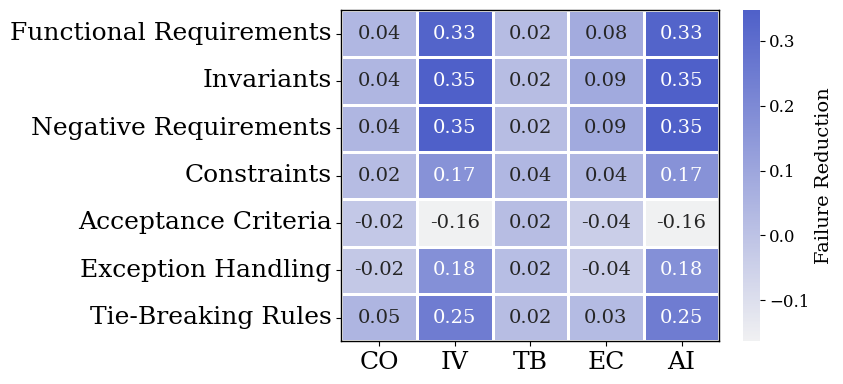

In [6]:
# ==========================================
# RQ3 Heatmap: Requirement Elements × Failure Modes
# Fixed version for Google Colab
# Upload exactly:
#   1) RQ3.csv
#   2) failure_modes_phase1.csv
# ==========================================

# !pip -q install pandas numpy matplotlib seaborn openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
# from google.colab import files

# -----------------------------
# Style aligned with your RQ1/RQ2 figures
# -----------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.0,
    "grid.color": "#bdbdbd",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.8,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})


rq3 = pd.read_csv("/Users/elmiraonagh/Desktop/Research/Specification_proj_w26/specification_repo/Specification-Completeness-and-Failure-Modes-in-LLM-Assisted-Development/Datasets/Anonymized/RQ3.csv")
fm = pd.read_csv("/Users/elmiraonagh/Desktop/Research/Specification_proj_w26/specification_repo/Specification-Completeness-and-Failure-Modes-in-LLM-Assisted-Development/Datasets/Anonymized/failure_modes_phase1.csv")

# print("\nRQ3 file:", rq3_file)
print("RQ3 columns:", rq3.columns.tolist())
# print("\nFailure-mode file:", fm_file)
print("Failure-mode columns:", fm.columns.tolist())

# -----------------------------
# Check required columns
# -----------------------------
req_cols = ["anon_id", "Has_AC", "Has_Excp", "Has_FR", "Has_INV", "Has_Neg_RE", "Has_TB", "Has_const"]
missing_req = [c for c in req_cols if c not in rq3.columns]
if missing_req:
    raise ValueError(f"RQ3.csv is missing required columns: {missing_req}")

if "anon_id" not in fm.columns or "failed_categories" not in fm.columns:
    raise ValueError("failure_modes_phase1.csv must contain 'id' and 'failed_categories' columns.")

# -----------------------------
# Keep only needed columns
# -----------------------------
rq3 = rq3[req_cols].copy()

# Convert requirement indicators to numeric 0/1
for c in req_cols[1:]:
    rq3[c] = pd.to_numeric(rq3[c], errors="coerce").fillna(0).astype(int)

# -----------------------------
# Parse failure categories
# -----------------------------
def parse_list(x):
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    try:
        return ast.literal_eval(x)
    except Exception:
        return []

fm["failed_categories"] = fm["failed_categories"].apply(parse_list)

failure_modes = ["CO", "IV", "TB", "EC", "AI"]
for mode in failure_modes:
    fm[mode] = fm["failed_categories"].apply(lambda lst: 1 if mode in set(lst) else 0)

fm = fm[["anon_id"] + failure_modes].copy()

# -----------------------------
# Merge on id
# -----------------------------
merged = pd.merge(rq3, fm, on="anon_id", how="inner")

print("\nRows in RQ3.csv:", len(rq3))
print("Rows in failure_modes_phase1.csv:", len(fm))
print("Rows after merge:", len(merged))

if len(merged) == 0:
    raise ValueError("Merge produced 0 rows. Check that both files use the same participant IDs.")

# -----------------------------
# Compute reduction matrix
# Reduction = P(failure | req absent) - P(failure | req present)
# -----------------------------
req_map = {
    "Has_FR": "Functional Requirements",
    "Has_INV": "Invariants",
    "Has_Neg_RE": "Negative Requirements",
    "Has_const": "Constraints",
    "Has_AC": "Acceptance Criteria",
    "Has_Excp": "Exception Handling",
    "Has_TB": "Tie-Breaking Rules"
}

heatmap = pd.DataFrame(index=req_map.values(), columns=failure_modes, dtype=float)

for req_col, req_label in req_map.items():
    for mode in failure_modes:
        absent = merged.loc[merged[req_col] == 0, mode]
        present = merged.loc[merged[req_col] == 1, mode]

        if len(absent) == 0 or len(present) == 0:
            heatmap.loc[req_label, mode] = np.nan
        else:
            heatmap.loc[req_label, mode] = absent.mean() - present.mean()

print("\nReduction matrix:")
print(heatmap)

# -----------------------------
# Plot heatmap
# -----------------------------
fig, ax = plt.subplots(figsize=(8.4, 4))
ax.set_facecolor("#e6e6e6")

# Darker blue palette to match your figures
cmap = sns.light_palette("#4f60c9", as_cmap=True)

sns.heatmap(
    heatmap,
    annot=True,
    fmt=".2f",
    cmap=cmap,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": "Failure Reduction"},
    ax=ax, annot_kws={"size": 14} 
)

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.0)

plt.tight_layout()

pdf_name = "RQ3_requirement_failure_heatmap.pdf"
png_name = "RQ3_requirement_failure_heatmap.png"
plt.savefig(pdf_name, bbox_inches="tight")
plt.savefig(png_name, dpi=300, bbox_inches="tight")
plt.show()
